# Exploratory Data Analysis (EDA)
This notebook performs an exploratory data analysis on the vehicle emissions dataset.

## 1. Importing Libraries and Loading Data

In [150]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("countries.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country                         188 non-null    object 
 1   Region                          188 non-null    object 
 2   Population (millions)           188 non-null    float64
 3   HDI                             172 non-null    float64
 4   GDP per Capita                  173 non-null    object 
 5   Cropland Footprint              173 non-null    float64
 6   Grazing Footprint               173 non-null    float64
 7   Forest Footprint                173 non-null    float64
 8   Carbon Footprint                173 non-null    float64
 9   Fish Footprint                  173 non-null    float64
 10  Total Ecological Footprint      188 non-null    float64
 11  Cropland                        173 non-null    float64
 12  Grazing Land                    173 

,Country,Region,Population (millions),HDI,GDP per Capita,Cropland Footprint,Grazing Footprint,Forest Footprint,Carbon Footprint,Fish Footprint,...,Cropland,Grazing Land,Forest Land,Fishing Water,Urban Land,Total Biocapacity,Biocapacity Deficit or Reserve,Earths Required,Countries Required,Data Quality
0,Afghanistan,Middle East/Central Asia,29.82,0.46,$614.66,0.30,0.20,0.08,0.18,0.00,...,0.24,0.20,0.02,0.00,0.04,0.50,-0.30,0.46,1.60,6
1,Albania,Northern/Eastern Europe,3.16,0.73,"$4,534.37",0.78,0.22,0.25,0.87,0.02,...,0.55,0.21,0.29,0.07,0.06,1.18,-1.03,1.27,1.87,6
2,Algeria,Africa,38.48,0.73,"$5,430.57",0.60,0.16,0.17,1.14,0.01,...,0.24,0.27,0.03,0.01,0.03,0.59,-1.53,1.22,3.61,5
3,Angola,Africa,20.82,0.52,"$4,665.91",0.33,0.15,0.12,0.20,0.09,...,0.20,1.42,0.64,0.26,0.04,2.55,1.61,0.54,0.37,6
4,Antigua and Barbuda,Latin America,0.09,0.78,"$13,205.10",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.94,-4.44,3.11,5.70,2


## 2. Data Overview
### 2.1 Checking for Missing Values and Data Types

In [151]:
df.isnull().sum()

Country                            0
Region                             0
Population (millions)              0
HDI                               16
GDP per Capita                    15
Cropland Footprint                15
Grazing Footprint                 15
Forest Footprint                  15
Carbon Footprint                  15
Fish Footprint                    15
Total Ecological Footprint         0
Cropland                          15
Grazing Land                      15
Forest Land                       15
Fishing Water                     15
Urban Land                        15
Total Biocapacity                  0
Biocapacity Deficit or Reserve     0
Earths Required                    0
Countries Required                 0
Data Quality                       0
dtype: int64

In [152]:
df.columns

Index(['Country', 'Region', 'Population (millions)', 'HDI', 'GDP per Capita',
       'Cropland Footprint', 'Grazing Footprint', 'Forest Footprint',
       'Carbon Footprint', 'Fish Footprint', 'Total Ecological Footprint',
       'Cropland', 'Grazing Land', 'Forest Land', 'Fishing Water',
       'Urban Land', 'Total Biocapacity', 'Biocapacity Deficit or Reserve',
       'Earths Required', 'Countries Required', 'Data Quality'],
      dtype='object')

In [153]:
df.dtypes

Country                            object
Region                             object
Population (millions)             float64
HDI                               float64
GDP per Capita                     object
Cropland Footprint                float64
Grazing Footprint                 float64
Forest Footprint                  float64
Carbon Footprint                  float64
Fish Footprint                    float64
Total Ecological Footprint        float64
Cropland                          float64
Grazing Land                      float64
Forest Land                       float64
Fishing Water                     float64
Urban Land                        float64
Total Biocapacity                 float64
Biocapacity Deficit or Reserve    float64
Earths Required                   float64
Countries Required                float64
Data Quality                       object
dtype: object

In [154]:
percentage=round(df.isnull().sum()/len(df),2)*100
percentage

Country                           0.0
Region                            0.0
Population (millions)             0.0
HDI                               9.0
GDP per Capita                    8.0
Cropland Footprint                8.0
Grazing Footprint                 8.0
Forest Footprint                  8.0
Carbon Footprint                  8.0
Fish Footprint                    8.0
Total Ecological Footprint        0.0
Cropland                          8.0
Grazing Land                      8.0
Forest Land                       8.0
Fishing Water                     8.0
Urban Land                        8.0
Total Biocapacity                 0.0
Biocapacity Deficit or Reserve    0.0
Earths Required                   0.0
Countries Required                0.0
Data Quality                      0.0
dtype: float64

In [155]:
df=df.drop(columns="Fish Footprint")
df

,Country,Region,Population (millions),HDI,GDP per Capita,Cropland Footprint,Grazing Footprint,Forest Footprint,Carbon Footprint,Total Ecological Footprint,Cropland,Grazing Land,Forest Land,Fishing Water,Urban Land,Total Biocapacity,Biocapacity Deficit or Reserve,Earths Required,Countries Required,Data Quality
0,Afghanistan,Middle East/Central Asia,29.82,0.46,$614.66,0.30,0.20,0.08,0.18,0.79,0.24,0.20,0.02,0.00,0.04,0.50,-0.30,0.46,1.60,6
1,Albania,Northern/Eastern Europe,3.16,0.73,"$4,534.37",0.78,0.22,0.25,0.87,2.21,0.55,0.21,0.29,0.07,0.06,1.18,-1.03,1.27,1.87,6
2,Algeria,Africa,38.48,0.73,"$5,430.57",0.60,0.16,0.17,1.14,2.12,0.24,0.27,0.03,0.01,0.03,0.59,-1.53,1.22,3.61,5
3,Angola,Africa,20.82,0.52,"$4,665.91",0.33,0.15,0.12,0.20,0.93,0.20,1.42,0.64,0.26,0.04,2.55,1.61,0.54,0.37,6
4,Antigua and Barbuda,Latin America,0.09,0.78,"$13,205.10",NaN,NaN,NaN,NaN,5.38,NaN,NaN,NaN,NaN,NaN,0.94,-4.44,3.11,5.70,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Viet Nam,Asia-Pacific,90.80,0.66,"$1,532.31",0.50,0.01,0.19,0.79,1.65,0.55,0.01,0.17,0.16,0.10,1.00,-0.65,0.95,1.66,6
184,Wallis and Futuna Islands,Asia-Pacific,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2.07,NaN,NaN,NaN,NaN,NaN,1.51,-0.56,1.19,1.37,3T
185,Yemen,Middle East/Central Asia,23.85,0.50,"$1,302.30",0.34,0.14,0.04,0.42,1.03,0.09,0.12,0.04,0.20,0.04,0.50,-0.53,0.59,2.06,5
186,Zambia,Africa,14.08,0.58,"$1,740.64",0.19,0.18,0.33,0.24,0.99,0.24,0.94,0.99,0.02,0.04,2.23,1.24,0.57,0.44,6


In [156]:
df=df.drop(columns="Biocapacity Deficit or Reserve")
df

,Country,Region,Population (millions),HDI,GDP per Capita,Cropland Footprint,Grazing Footprint,Forest Footprint,Carbon Footprint,Total Ecological Footprint,Cropland,Grazing Land,Forest Land,Fishing Water,Urban Land,Total Biocapacity,Earths Required,Countries Required,Data Quality
0,Afghanistan,Middle East/Central Asia,29.82,0.46,$614.66,0.30,0.20,0.08,0.18,0.79,0.24,0.20,0.02,0.00,0.04,0.50,0.46,1.60,6
1,Albania,Northern/Eastern Europe,3.16,0.73,"$4,534.37",0.78,0.22,0.25,0.87,2.21,0.55,0.21,0.29,0.07,0.06,1.18,1.27,1.87,6
2,Algeria,Africa,38.48,0.73,"$5,430.57",0.60,0.16,0.17,1.14,2.12,0.24,0.27,0.03,0.01,0.03,0.59,1.22,3.61,5
3,Angola,Africa,20.82,0.52,"$4,665.91",0.33,0.15,0.12,0.20,0.93,0.20,1.42,0.64,0.26,0.04,2.55,0.54,0.37,6
4,Antigua and Barbuda,Latin America,0.09,0.78,"$13,205.10",NaN,NaN,NaN,NaN,5.38,NaN,NaN,NaN,NaN,NaN,0.94,3.11,5.70,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Viet Nam,Asia-Pacific,90.80,0.66,"$1,532.31",0.50,0.01,0.19,0.79,1.65,0.55,0.01,0.17,0.16,0.10,1.00,0.95,1.66,6
184,Wallis and Futuna Islands,Asia-Pacific,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2.07,NaN,NaN,NaN,NaN,NaN,1.51,1.19,1.37,3T
185,Yemen,Middle East/Central Asia,23.85,0.50,"$1,302.30",0.34,0.14,0.04,0.42,1.03,0.09,0.12,0.04,0.20,0.04,0.50,0.59,2.06,5
186,Zambia,Africa,14.08,0.58,"$1,740.64",0.19,0.18,0.33,0.24,0.99,0.24,0.94,0.99,0.02,0.04,2.23,0.57,0.44,6


In [157]:
df['HDI'] = df['HDI'].fillna(df['HDI'].median())

In [158]:
df['GDP per Capita'] = df['GDP per Capita'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_17700\3374754853.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['GDP per Capita'] = df['GDP per Capita'].replace('[\$,]', '', regex=True).astype(float)


In [159]:
df['GDP per Capita'] = df['GDP per Capita'].fillna(df['GDP per Capita'].median())

In [160]:
df['Cropland Footprint'] = df['Cropland Footprint'].fillna(df['Cropland Footprint'].median())

In [161]:
df['Grazing Footprint'] = df['Grazing Footprint'].fillna(df['Grazing Footprint'].median())

In [162]:
df['Forest Footprint'] = df['Forest Footprint'].fillna(df['Forest Footprint'].median())

In [163]:
df['Carbon Footprint'] = df['Carbon Footprint'].fillna(df['Carbon Footprint'].median())

In [164]:
df['Cropland'] = df['Cropland'].fillna(df['Cropland'].median())

In [165]:
df['Grazing Land'] = df['Grazing Land'].fillna(df['Grazing Land'].median())

In [166]:
df['Forest Land'] = df['Forest Land'].fillna(df['Forest Land'].median())

In [167]:
df['Urban land'] = df['Forest Land'].fillna(df['Forest Land'].median())

In [168]:
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Country                        0
Region                         0
Population (millions)          0
HDI                            0
GDP per Capita                 0
Cropland Footprint             0
Grazing Footprint              0
Forest Footprint               0
Carbon Footprint               0
Total Ecological Footprint     0
Cropland                       0
Grazing Land                   0
Forest Land                    0
Fishing Water                 15
Urban Land                    15
Total Biocapacity              0
Earths Required                0
Countries Required             0
Data Quality                   0
Urban land                     0
dtype: int64


In [169]:
df.columns=df.columns.str.replace(" ","_")
df.columns

Index(['Country', 'Region', 'Population_(millions)', 'HDI', 'GDP_per_Capita',
       'Cropland_Footprint', 'Grazing_Footprint', 'Forest_Footprint',
       'Carbon_Footprint', 'Total_Ecological_Footprint', 'Cropland',
       'Grazing_Land', 'Forest_Land', 'Fishing_Water', 'Urban_Land',
       'Total_Biocapacity', 'Earths_Required', 'Countries_Required',
       'Data_Quality', 'Urban_land'],
      dtype='object')

In [170]:
df.drop_duplicates(keep="first")

,Country,Region,Population_(millions),HDI,GDP_per_Capita,Cropland_Footprint,Grazing_Footprint,Forest_Footprint,Carbon_Footprint,Total_Ecological_Footprint,Cropland,Grazing_Land,Forest_Land,Fishing_Water,Urban_Land,Total_Biocapacity,Earths_Required,Countries_Required,Data_Quality,Urban_land
0,Afghanistan,Middle East/Central Asia,29.82,0.46,614.66,0.30,0.20,0.08,0.18,0.79,0.24,0.20,0.02,0.00,0.04,0.50,0.46,1.60,6,0.02
1,Albania,Northern/Eastern Europe,3.16,0.73,4534.37,0.78,0.22,0.25,0.87,2.21,0.55,0.21,0.29,0.07,0.06,1.18,1.27,1.87,6,0.29
2,Algeria,Africa,38.48,0.73,5430.57,0.60,0.16,0.17,1.14,2.12,0.24,0.27,0.03,0.01,0.03,0.59,1.22,3.61,5,0.03
3,Angola,Africa,20.82,0.52,4665.91,0.33,0.15,0.12,0.20,0.93,0.20,1.42,0.64,0.26,0.04,2.55,0.54,0.37,6,0.64
4,Antigua and Barbuda,Latin America,0.09,0.78,13205.10,0.52,0.18,0.26,1.14,5.38,0.35,0.12,0.34,NaN,NaN,0.94,3.11,5.70,2,0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Viet Nam,Asia-Pacific,90.80,0.66,1532.31,0.50,0.01,0.19,0.79,1.65,0.55,0.01,0.17,0.16,0.10,1.00,0.95,1.66,6,0.17
184,Wallis and Futuna Islands,Asia-Pacific,0.01,0.72,5430.57,0.52,0.18,0.26,1.14,2.07,0.35,0.12,0.34,NaN,NaN,1.51,1.19,1.37,3T,0.34
185,Yemen,Middle East/Central Asia,23.85,0.50,1302.30,0.34,0.14,0.04,0.42,1.03,0.09,0.12,0.04,0.20,0.04,0.50,0.59,2.06,5,0.04
186,Zambia,Africa,14.08,0.58,1740.64,0.19,0.18,0.33,0.24,0.99,0.24,0.94,0.99,0.02,0.04,2.23,0.57,0.44,6,0.99


No missing values

### 2.2 Summary Statistics

In [171]:
df.describe(include='all')

,Country,Region,Population_(millions),HDI,GDP_per_Capita,Cropland_Footprint,Grazing_Footprint,Forest_Footprint,Carbon_Footprint,Total_Ecological_Footprint,Cropland,Grazing_Land,Forest_Land,Fishing_Water,Urban_Land,Total_Biocapacity,Earths_Required,Countries_Required,Data_Quality,Urban_land
count,188,188,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,173.000000,173.000000,188.000000,188.000000,188.000000,188,188.000000
unique,188,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN
top,Afghanistan,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
freq,1,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,NaN
mean,NaN,NaN,37.342372,0.689223,13535.578511,0.573564,0.256543,0.364734,1.751862,3.317606,0.517340,0.429734,2.290106,0.595145,0.067110,4.019681,1.915745,4.037397,NaN,2.290106
std,NaN,NaN,140.756836,0.149511,20212.529442,0.341493,0.338407,0.346020,1.829498,2.370931,0.646918,0.977476,10.176485,1.661872,0.054844,11.689075,1.369624,12.444616,NaN,10.176485
min,NaN,NaN,0.000000,0.340000,276.690000,0.070000,0.000000,0.010000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050000,0.240000,0.020000,NaN,0.000000
25%,NaN,NaN,2.037500,0.577500,1627.637500,0.357500,0.090000,0.170000,0.465000,1.482500,0.200000,0.040000,0.070000,0.030000,0.030000,0.675000,0.855000,0.942500,NaN,0.070000
50%,NaN,NaN,7.970000,0.720000,5430.570000,0.520000,0.180000,0.260000,1.140000,2.740000,0.350000,0.120000,0.340000,0.110000,0.050000,1.310000,1.580000,1.705000,NaN,0.340000
75%,NaN,NaN,24.870000,0.790000,13818.175000,0.672500,0.300000,0.450000,2.422500,4.640000,0.562500,0.310000,0.967500,0.370000,0.090000,2.815000,2.677500,2.847500,NaN,0.967500


### 2.3 Basic operations

In [172]:
df.shape

(188, 20)

19 different **variables** with a **sample size** of 10000

In [173]:
df.index

RangeIndex(start=0, stop=188, step=1)

## 3. Distribution of Continuous variables

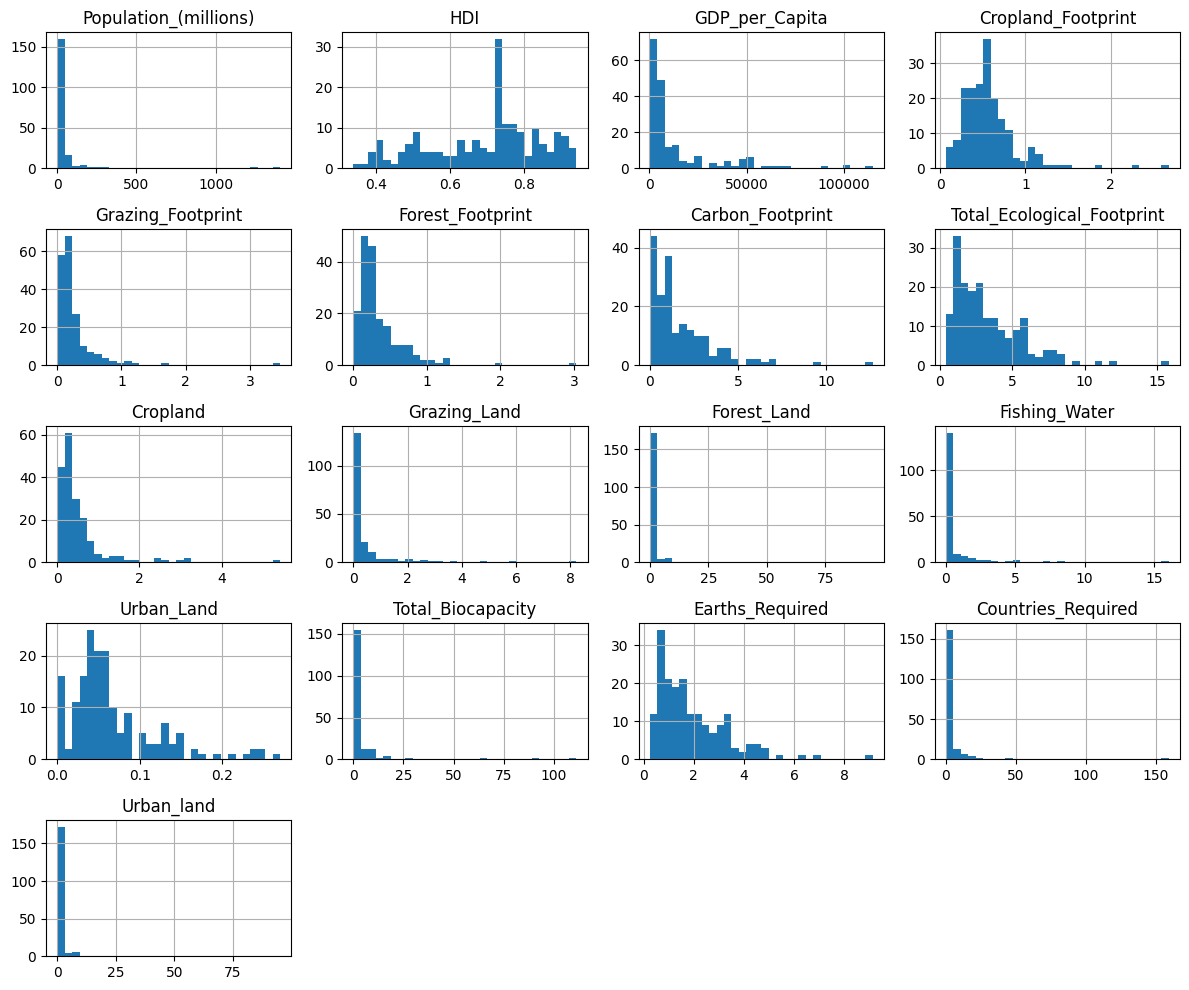

In [174]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

# 4: Detection of outliers

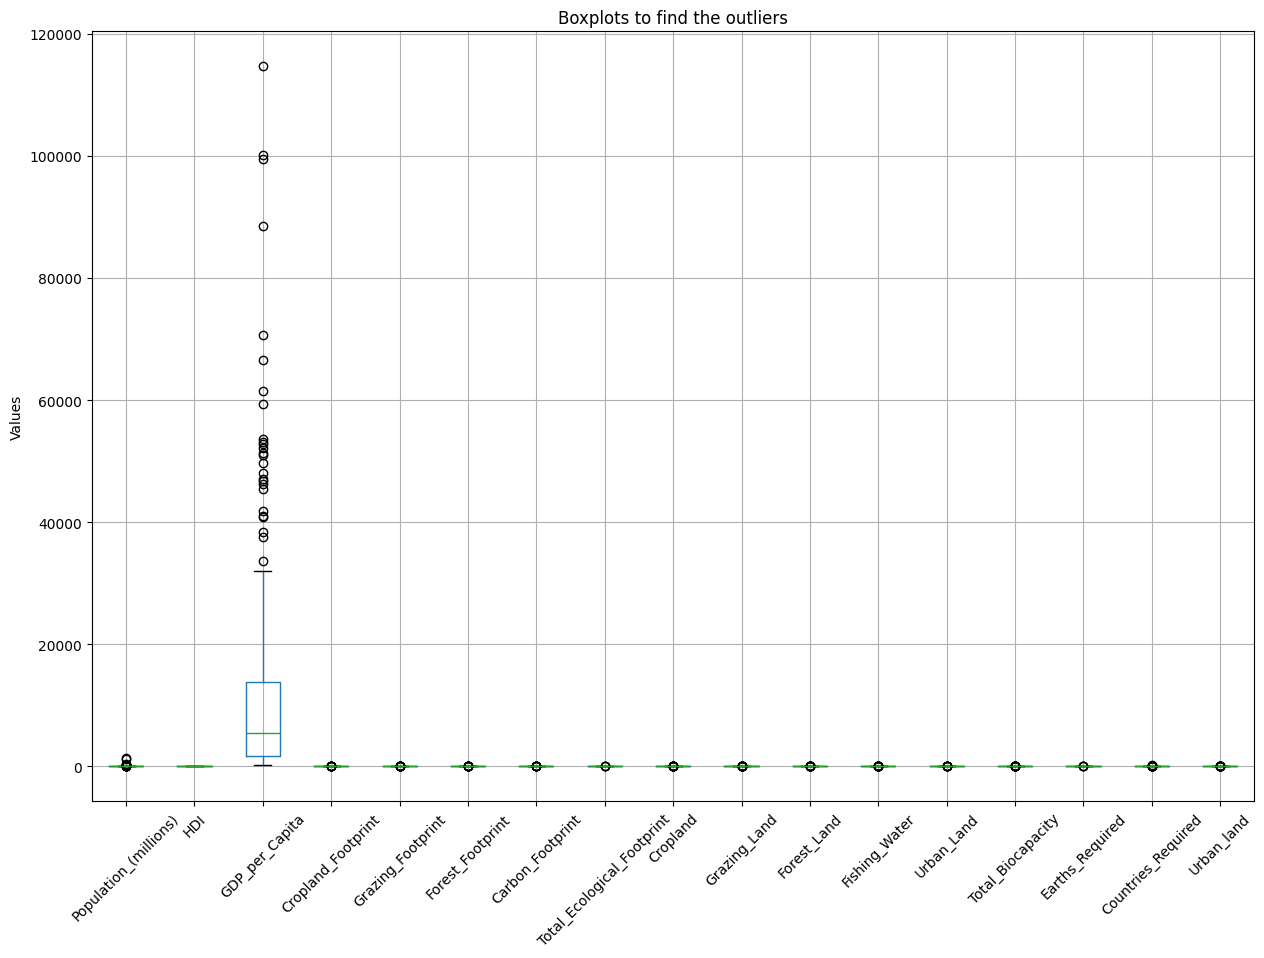

In [175]:
col=['Population_(millions)', 'HDI', 'GDP_per_Capita',
       'Cropland_Footprint', 'Grazing_Footprint', 'Forest_Footprint',
       'Carbon_Footprint', 'Total_Ecological_Footprint', 'Cropland',
       'Grazing_Land', 'Forest_Land', 'Fishing_Water', 'Urban_Land',
       'Total_Biocapacity',
       'Earths_Required', 'Countries_Required', 'Urban_land']
plt.figure(figsize=(15, 10))
df[col].boxplot(rot=45)
plt.title("Boxplots to find the outliers")
plt.ylabel("Values")
plt.show()


In [178]:
Q1 = df['Population_(millions)'].quantile(0.25)
Q3 = df['Population_(millions)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Population_(millions)'] < lower_bound) | (df['Population_(millions)'] > upper_bound)]
print(f"Number of outliers in 'Population_(millions)': {len(outliers)}")

print("\nOutlier Population_(millions)s:")
print(outliers['Population_(millions)'].describe())

#  Remove outliers
df_cleaned = df[(df['Population_(millions)'] >= lower_bound) & (df['Population_(millions)'] <= upper_bound)]

Number of outliers in 'Population_(millions)': 23

Outlier Population_(millions)s:
count      23.000000
mean      226.752174
std       352.761312
min        60.920000
25%        75.210000
50%        96.710000
75%       173.995000
max      1408.040000
Name: Population_(millions), dtype: float64


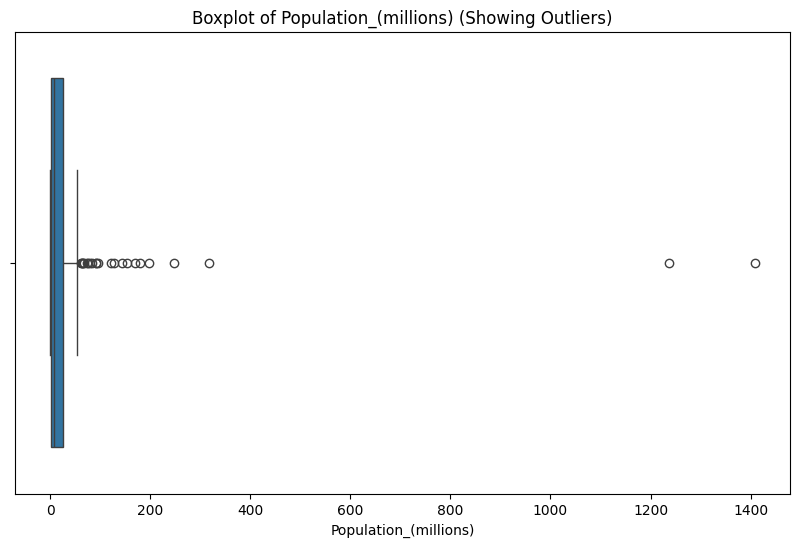

In [179]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Population_(millions)'])
plt.title('Boxplot of Population_(millions) (Showing Outliers)')
plt.xlabel('Population_(millions)')
plt.show()

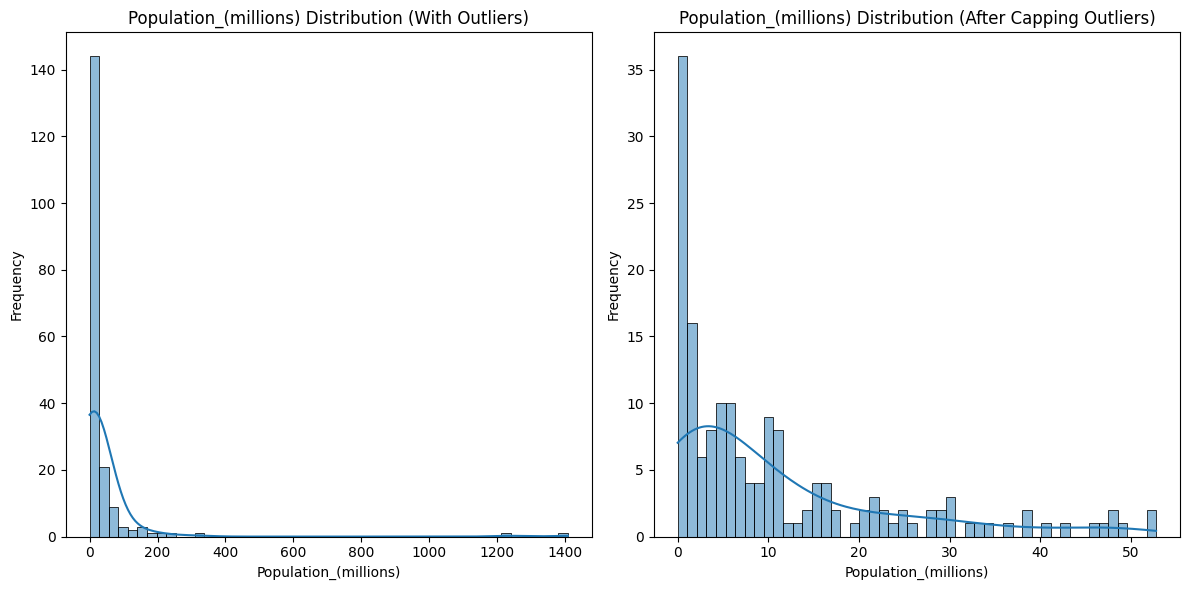

In [180]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Population_(millions)'], bins=50, kde=True)
plt.title('Population_(millions) Distribution (With Outliers)')
plt.xlabel('Population_(millions)')
plt.ylabel('Frequency')

# After handling outliers (using capped data)
plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['Population_(millions)'], bins=50, kde=True)
plt.title('Population_(millions) Distribution (After Capping Outliers)')
plt.xlabel('Population_(millions)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [181]:
Q1 = df['HDI'].quantile(0.25)
Q3 = df['HDI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['HDI'] < lower_bound) | (df['HDI'] > upper_bound)]
print(f"Number of outliers in 'HDI': {len(outliers)}")

print("\nOutlier 'HDIs:")
print(outliers['HDI'].describe())

#  Remove outliers
df_cleaned = df[(df['HDI'] >= lower_bound) & (df['HDI'] <= upper_bound)]

Number of outliers in 'HDI': 0

Outlier 'HDIs:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: HDI, dtype: float64


In [186]:
Q1 = df['GDP_per_Capita'].quantile(0.25)
Q3 = df['GDP_per_Capita'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['GDP_per_Capita'] < lower_bound) | (df['GDP_per_Capita'] > upper_bound)]
print(f"Number of outliers in 'GDP_per_Capita': {len(outliers)}")

print("\nOutlier GDP_per_Capita:")
print(outliers['GDP_per_Capita'].describe())

#  Remove outliers
df_cleaned = df[(df['GDP_per_Capita'] >= lower_bound) & (df['GDP_per_Capita'] <= upper_bound)]

Number of outliers in 'GDP_per_Capita': 26

Outlier GDP_per_Capita:
count        26.000000
mean      57358.611538
std       20995.698991
min       33718.900000
25%       45623.125000
50%       51117.150000
75%       60905.675000
max      114665.000000
Name: GDP_per_Capita, dtype: float64


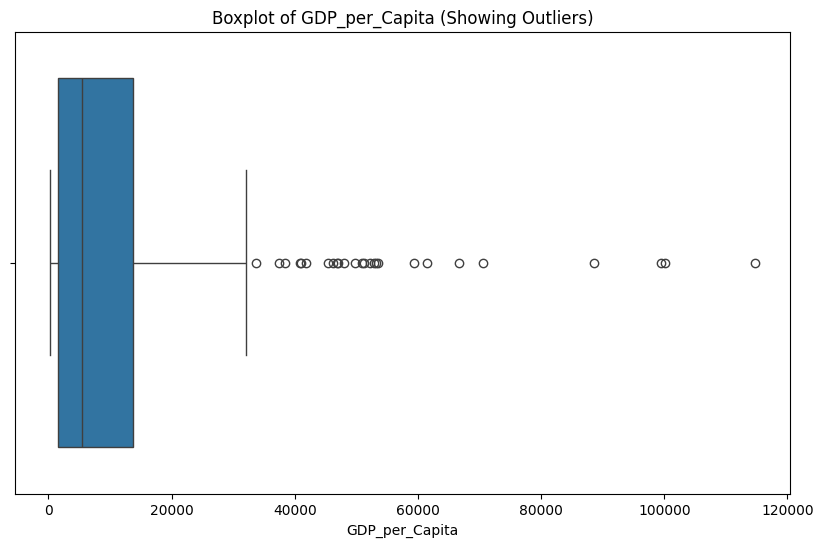

In [187]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['GDP_per_Capita'])
plt.title('Boxplot of GDP_per_Capita (Showing Outliers)')
plt.xlabel('GDP_per_Capita')
plt.show()

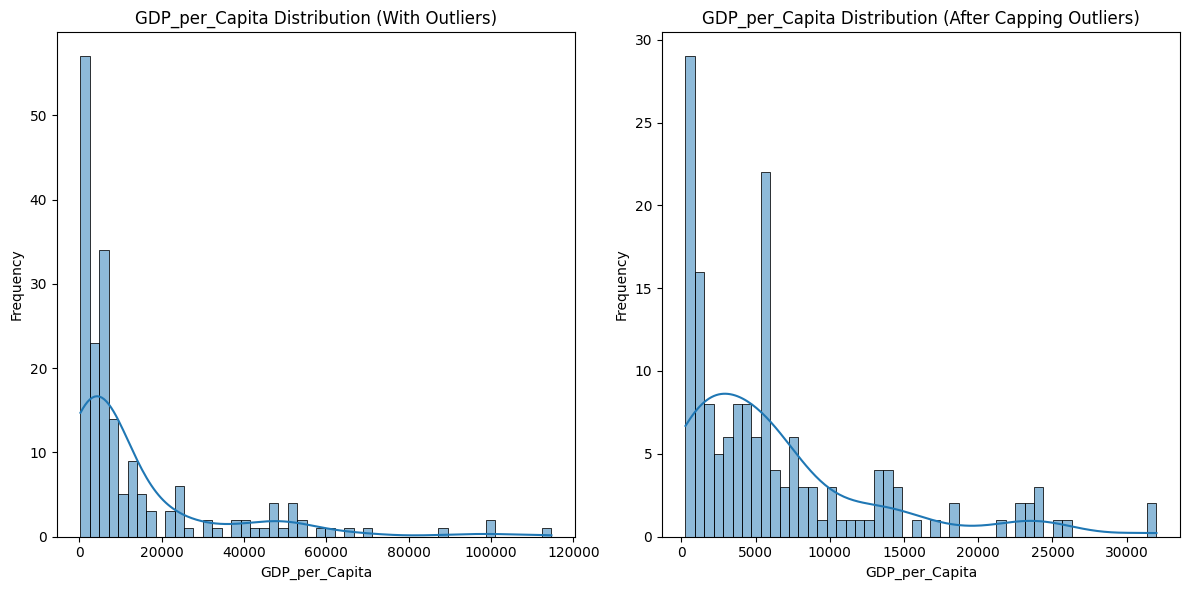

In [188]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['GDP_per_Capita'], bins=50, kde=True)
plt.title('GDP_per_Capita Distribution (With Outliers)')
plt.xlabel('GDP_per_Capita')
plt.ylabel('Frequency')

# After handling outliers (using capped data)
plt.subplot(1, 2, 2)
sns.histplot(df_cleaned['GDP_per_Capita'], bins=50, kde=True)
plt.title('GDP_per_Capita Distribution (After Capping Outliers)')
plt.xlabel('GDP_per_Capita')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 5: Multivariate Analysis

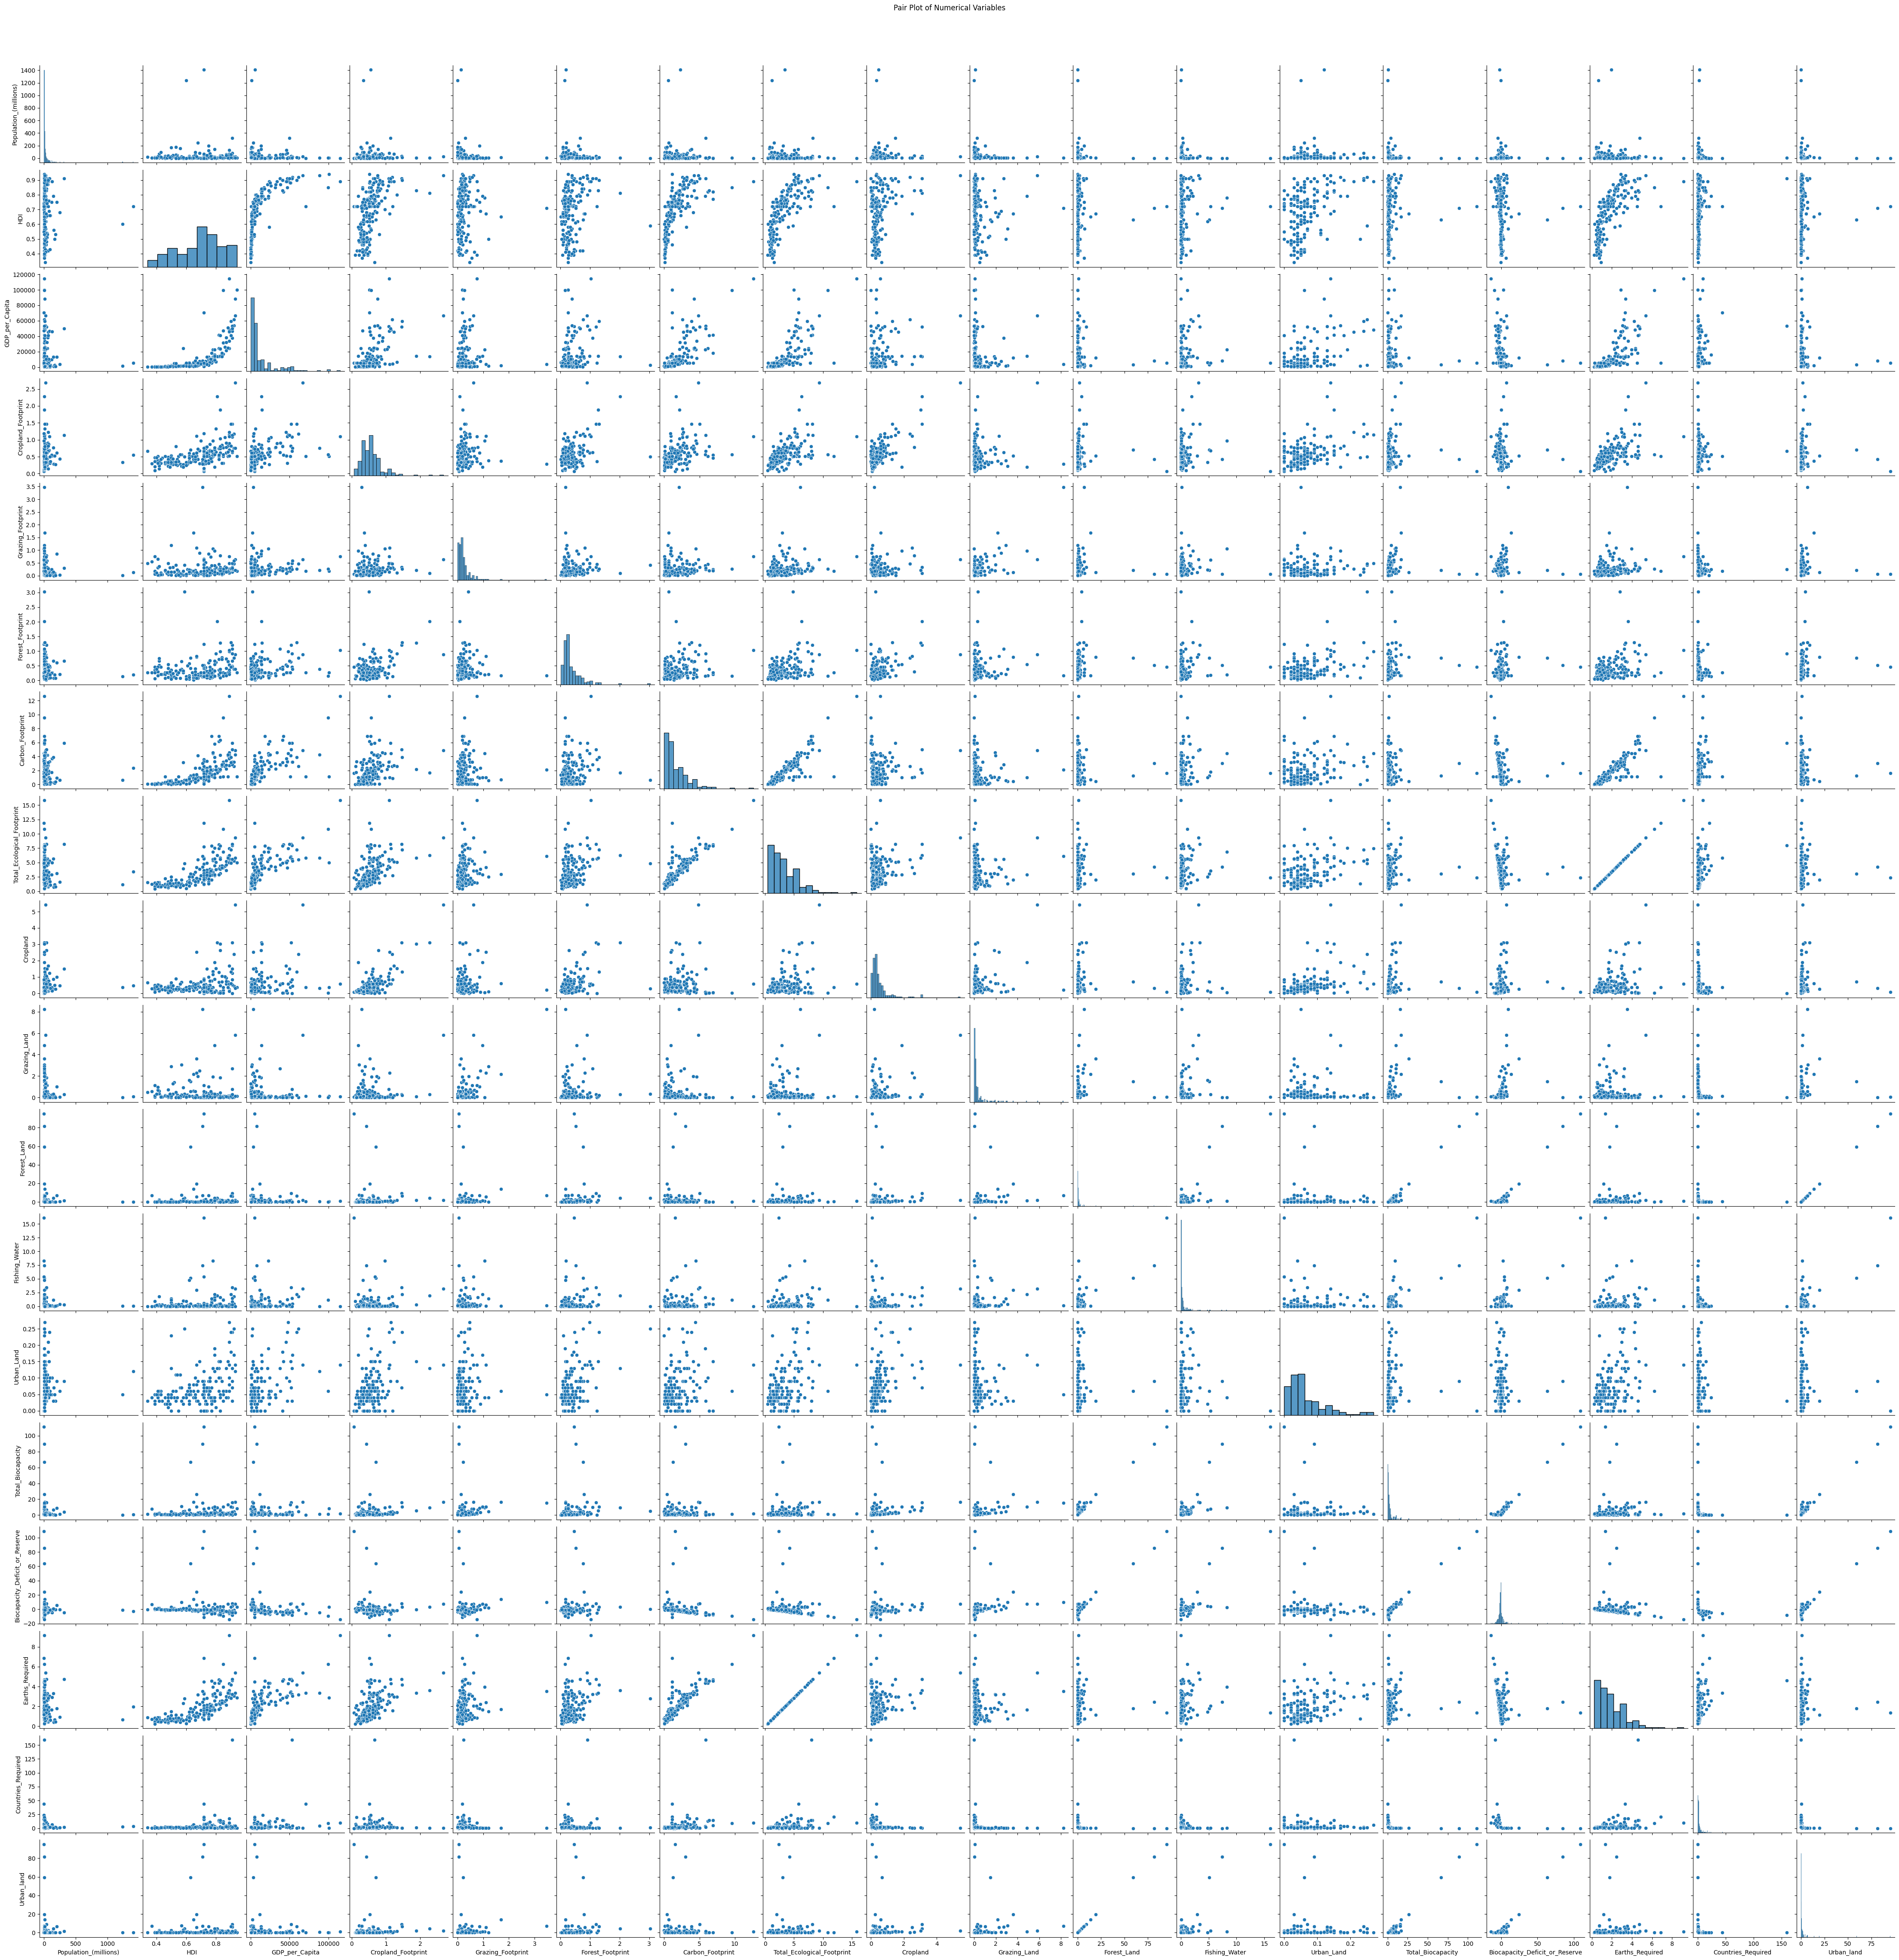

In [ ]:
sns.pairplot(df[col])
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()


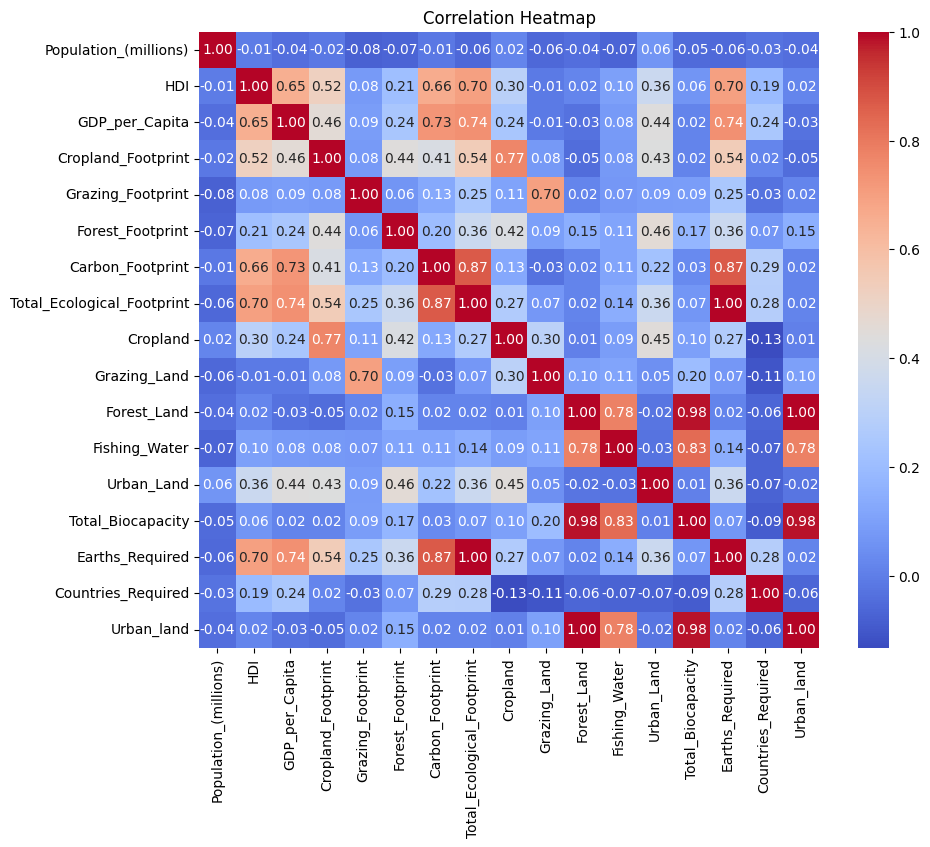

In [ ]:
corr_matrix = df[col].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()